In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn

from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP
from nnscaling.utils import (
    compute_model_accuracy,
    get_device,
    safetensors_metadata_parser,
)
from nnscaling.visualization import plot_decision_boundary

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
file_path = "/home/nsa325/work/nnscaling/model_saves/torus_model.safetensors"
model = MLP.load_model(file_path, in_features=3).eval()
model.summary()

{'config': '[10, 8, 6, 3]', 'dataset': 'TorusDataset', 'nonlinearity': 'relu', 'out_features': '2'}


Layer (type (var_name))                  Param #
MLP (MLP)                                --
+ Sequential (_features)                 --
|    + LinearLayer (0)                   --
|    |    + Linear (linear)              40
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (1)                   --
|    |    + Linear (linear)              88
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (2)                   --
|    |    + Linear (linear)              54
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (3)                   --
|    |    + Linear (linear)              21
|    |    + ReLU (activation_layer)      --
|    + LinearLayer (4)                   --
|    |    + Linear (linear)              8
Total params: 211
Trainable params: 211
Non-trainable params: 0

In [19]:
# Dataset config
metadata = safetensors_metadata_parser(file_path=file_path)
dataset_config = DatasetConfig(
    dataset_name=metadata["dataset"],
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [20]:
print(f"Testing Accuracy: {compute_model_accuracy(model, dataset)}")

Testing Accuracy: 1.0


RuntimeError: mat1 and mat2 shapes cannot be multiplied (10000x2 and 3x10)

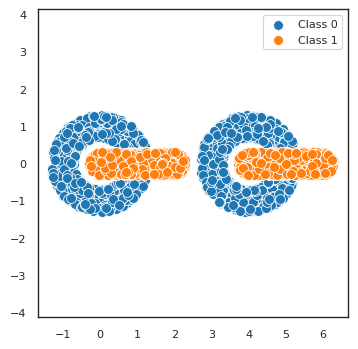

In [21]:
plot_decision_boundary(
    model,
    model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)